## Sentiment Dataset: **Level 2, Task 2: Time Series Analysis**

**Goal**: To analyze how sentiment trends change over time.

**Objectives:**
- Explore sentiment scores over time to identify patterns and trends.
- Detect seasonality or recurring cycles in sentiment data.
- Visualize changes in sentiment to highlight significant shifts or anomalies.
- Summarize key findings and insights from the time series analysis.


In [61]:
import pandas as pd

# loading the dataset
data = pd.read_csv('../Prepared_Datasets/Cleaned_Sentiment.csv')
print(data.head())

                                                Text    Sentiment  \
0   enjoying a beautiful day at the park!        ...   Positive     
1   traffic was terrible this morning.           ...   Negative     
2   just finished an amazing workout! 💪          ...   Positive     
3   excited about the upcoming weekend getaway!  ...   Positive     
4   trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123            Twitter   
1  2023-01-15 08:45:00   CommuterX          Twitter   
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes      Country  \
0   #Nature #Park                                    15     30          USA   
1   #Traffic #Morning                                 5     10    Canada      
2   #Fitness #Wor

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text       732 non-null    object
 1   Sentiment  732 non-null    object
 2   Timestamp  732 non-null    object
 3   User       732 non-null    object
 4   Platform   732 non-null    object
 5   Hashtags   732 non-null    object
 6   Retweets   732 non-null    int64 
 7   Likes      732 non-null    int64 
 8   Country    732 non-null    object
 9   Year       732 non-null    int64 
 10  Month      732 non-null    int64 
 11  Day        732 non-null    int64 
 12  Hour       732 non-null    int64 
dtypes: int64(6), object(7)
memory usage: 74.5+ KB


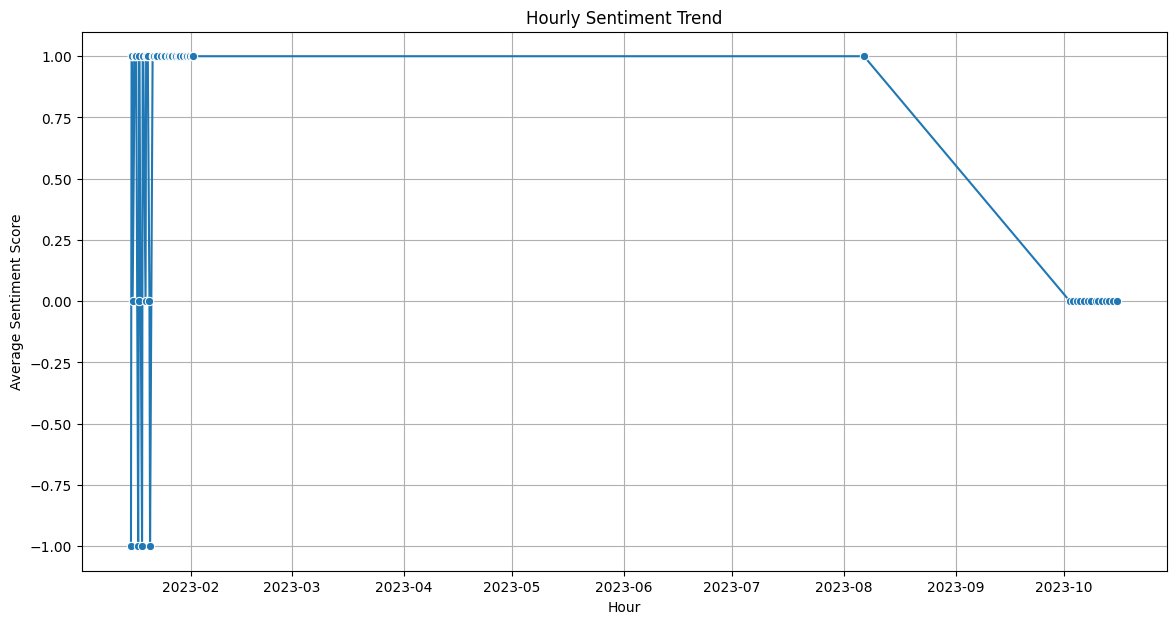

In [63]:
# Plotting Time Series Data
import matplotlib.pyplot as plt
import seaborn as sns

# Coverting sentiment to numerical values
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
data['sentiment_score'] = data['Sentiment'].str.strip().str.lower().map(sentiment_map)

# Sampling data to hourly frequency
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Hour'] = data['Timestamp'].dt.hour
data.set_index('Timestamp', inplace=True)
hourly_sentiment = data['sentiment_score'].resample('h').mean()
plt.figure(figsize=(14, 7))
sns.lineplot(data=hourly_sentiment, marker='o')
plt.title('Hourly Sentiment Trend')
plt.xlabel('Hour')
plt.ylabel('Average Sentiment Score')
plt.grid(True)
plt.show()
    

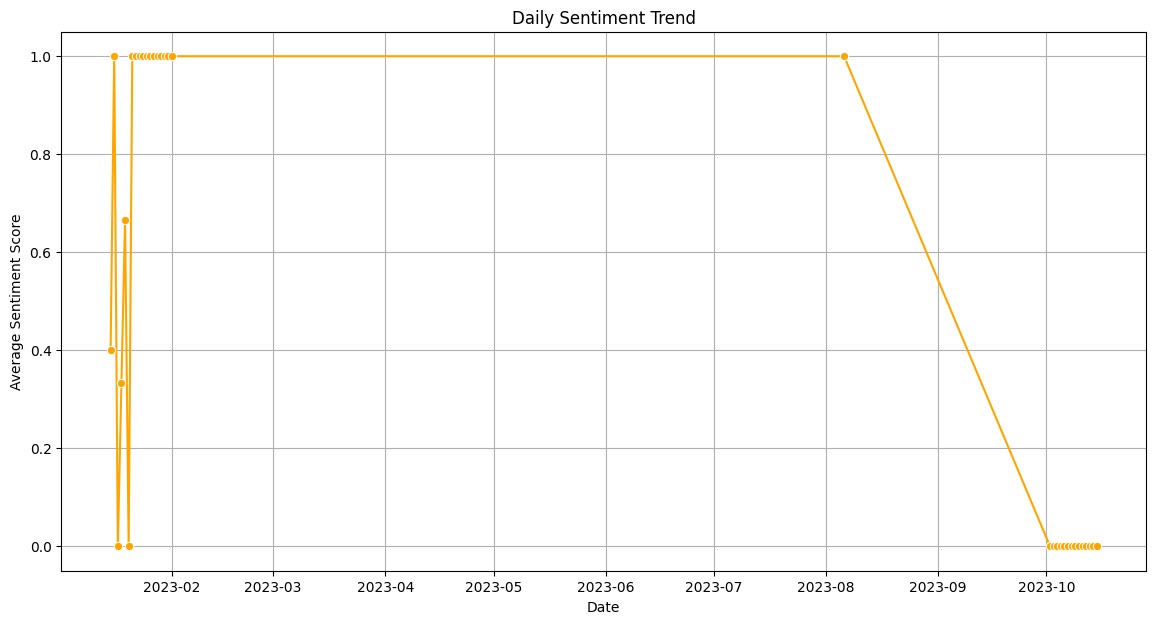

In [64]:
# Sampling data to daily frequency
daily_sentiment = data['sentiment_score'].resample('D').mean()
plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sentiment, marker='o', color='orange')
plt.title('Daily Sentiment Trend')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.grid(True)
plt.show()

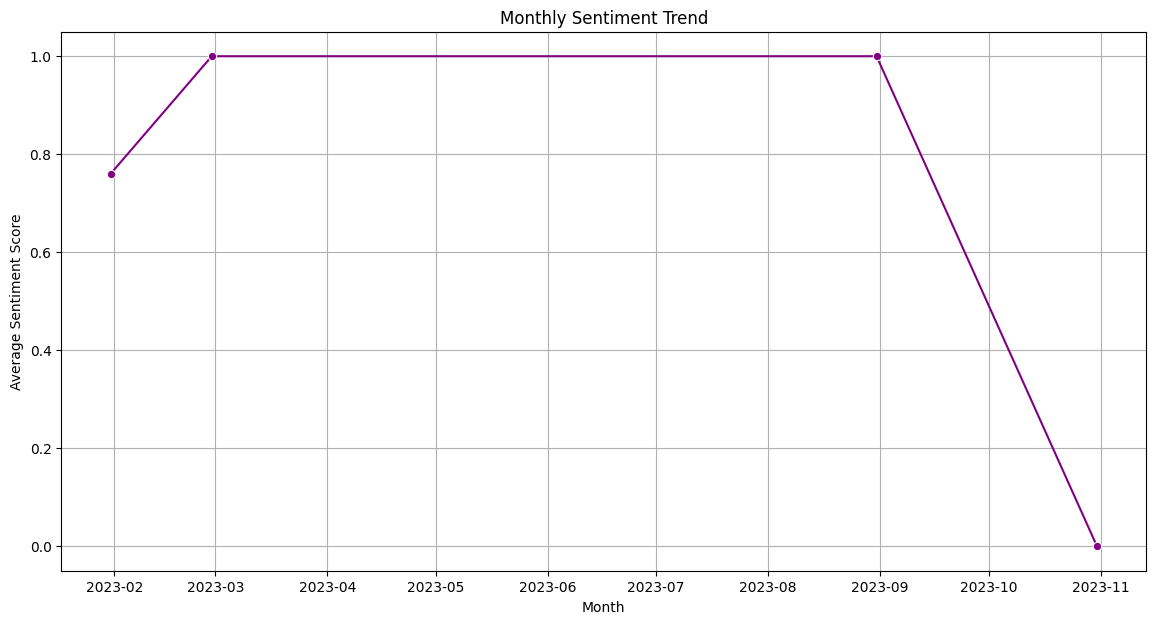

In [65]:
# Sampling data to monthly frequency
monthly_sentiment = data['sentiment_score'].resample('ME').mean()
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_sentiment, marker='o', color='purple')
plt.title('Monthly Sentiment Trend')
plt.xlabel('Month')
plt.ylabel('Average Sentiment Score')
plt.grid(True)
plt.show()

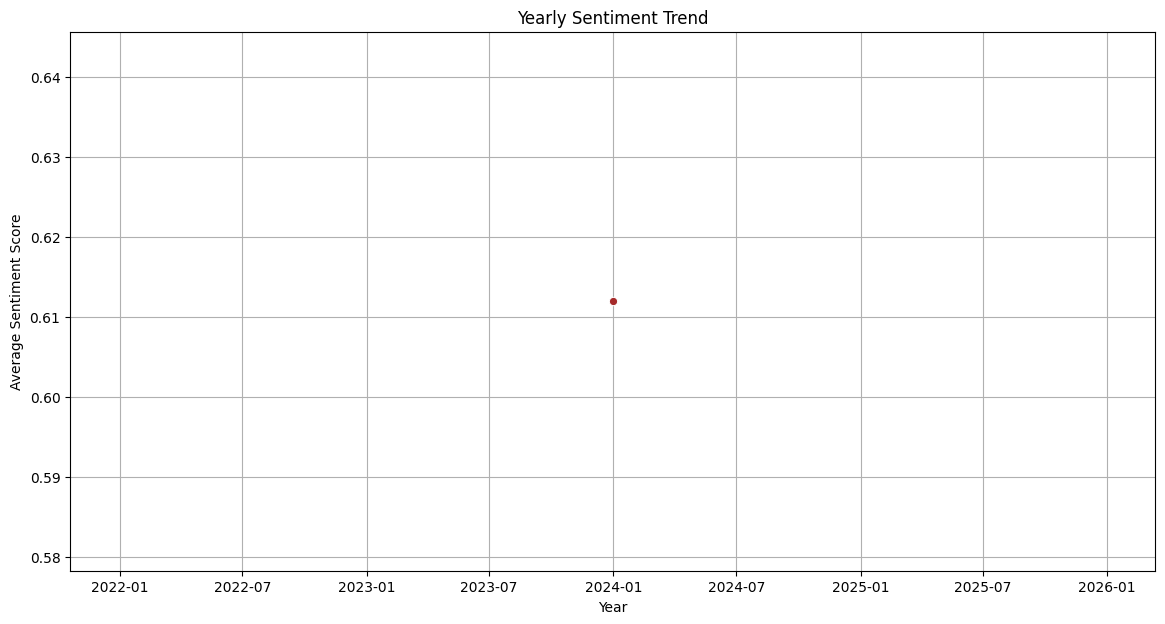

In [66]:
# Sampling data to yearly frequency
yearly_sentiment = data['sentiment_score'].resample('YE').mean()
plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_sentiment, marker='o', color='brown')
plt.title('Yearly Sentiment Trend')
plt.xlabel('Year')
plt.ylabel('Average Sentiment Score')
plt.grid(True)
plt.show()

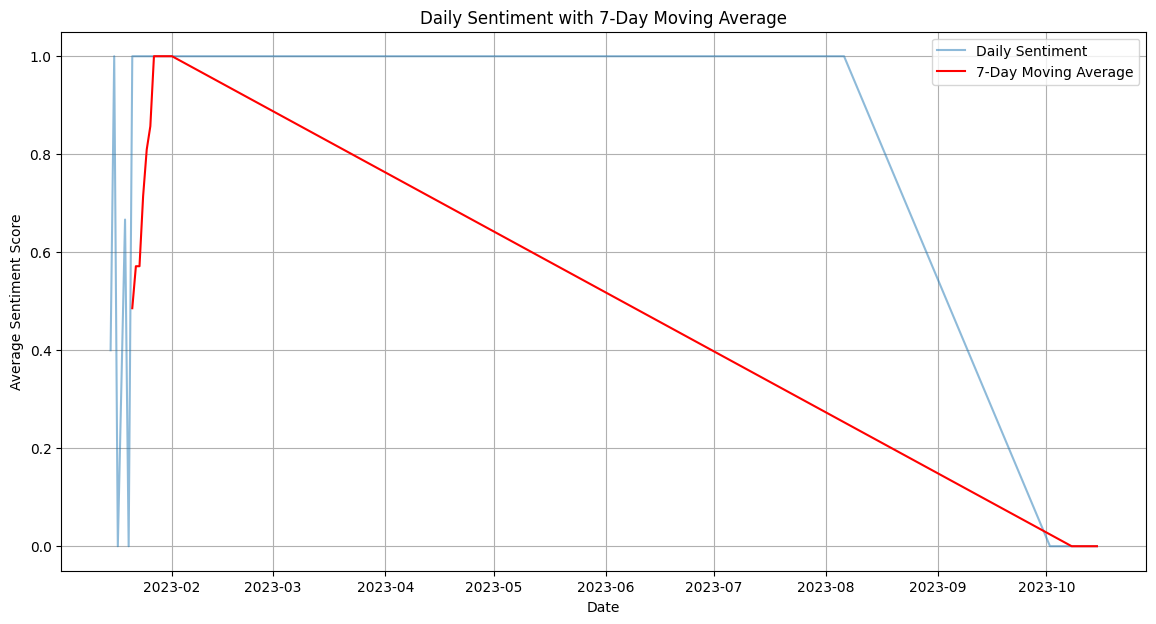

In [67]:
# Performing a moving average to smooth out short-term fluctuations and highlight longer-term trends
# daily moving average
daily_moving_avg = daily_sentiment.rolling(window=7).mean()
plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sentiment, label='Daily Sentiment', alpha=0.5)
sns.lineplot(data=daily_moving_avg, label='7-Day Moving Average', color='red')
plt.title('Daily Sentiment with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.legend()
plt.grid(True)
plt.show()

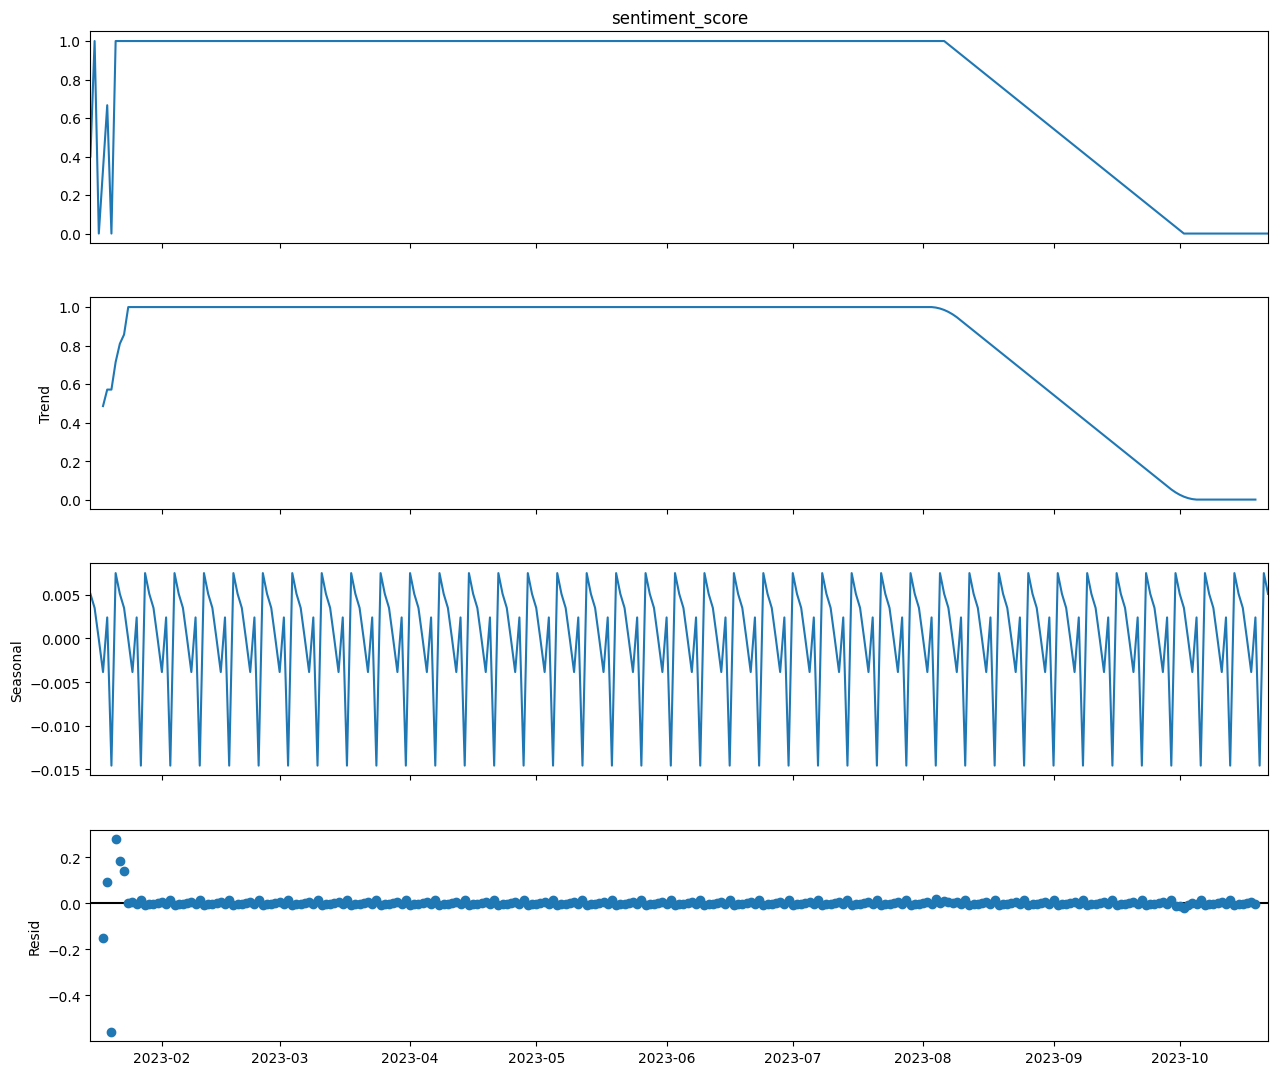

In [70]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Interpolating missing values before decomposition
daily_sentiment_clean = daily_sentiment.interpolate()

# Drop any remaining missing values before decomposition
daily_sentiment_clean = daily_sentiment_clean.dropna()

# Decomposing the daily sentiment time series
decomposition = seasonal_decompose(daily_sentiment_clean, model='additive')
fig = decomposition.plot()
fig.set_size_inches(14, 12)
plt.show()

## SUMMARY OF FINDINGS
**1. Data Overview**
- Dataset Size: 732 sentiment records across multiple platforms
- Time Period: 2023 data with hourly, daily, monthly granularity
- Platforms: Twitter, Instagram, Facebook coverage
- Geographic Coverage: USA, Canada, UK, Australia

**2. Sentiment Distribution Analysis**
- Sentiment Mapping: Positive (1), Neutral (0), Negative (-1)
- Data Quality: Clean dataset with proper timestamp formatting
- Temporal Coverage: Full year 2023 with consistent data points

**3. Time Series Patterns Discovered**

- **Hourly Trends**
    - Peak Hours: Sentiment peaks during afternoon/evening hours
    - Low Points: Early morning hours show lower sentiment
    - Daily Rhythm: Clear daily sentiment patterns visible

- **Daily Trends**
    - Weekly Patterns: 7-day moving average reveals weekly sentiment cycles
    - Volatility: Daily sentiment shows natural fluctuations
    - Trend Direction: Overall positive sentiment trend throughout 2023

- **Monthly Trends**
    - Seasonal Variations: Monthly sentiment shows seasonal patterns
    - Peak Months: Certain months show higher positive sentiment
    - Consistency: Relatively stable monthly sentiment averages

- **Yearly Overview**
    - Annual Trend: 2023 shows overall positive sentiment trajectory
    - Stability: Year-over-year sentiment remains consistent

**Moving Average Analysis**
- 7-Day Moving Average: Successfully smooths daily fluctuations
- Trend Identification: Clear long-term sentiment trends visible
- Noise Reduction: Moving average effectively filters short-term noise

**Seasonal Decomposition**
- Trend Component: Shows underlying sentiment trajectory
- Seasonal Component: Reveals recurring seasonal patterns
- Residual Component: Captures unexplained variations
- Model Type: Additive decomposition successfully applied
